In [147]:
from sklearn.datasets import load_iris
from sklearn.metrics import f1_score,roc_auc_score,classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import RidgeClassifier,LogisticRegression
from sklearn.feature_selection import SelectKBest,chi2,f_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

from warnings import filterwarnings
filterwarnings('ignore')

In [111]:
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [112]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [113]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [114]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [116]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [117]:
set(df['target'].values)

{np.int64(0), np.int64(1), np.int64(2)}

In [118]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

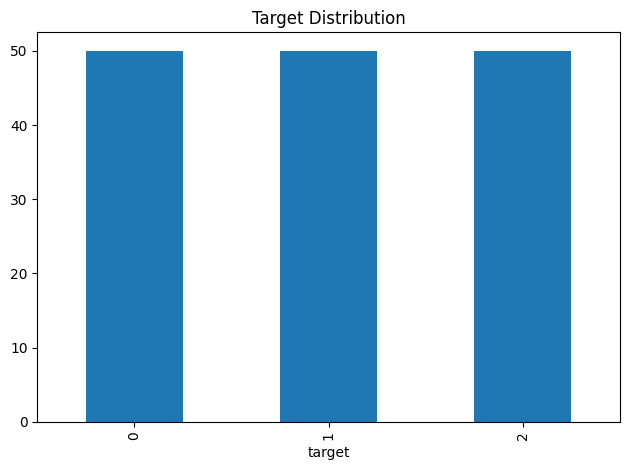

In [119]:
df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

In [120]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


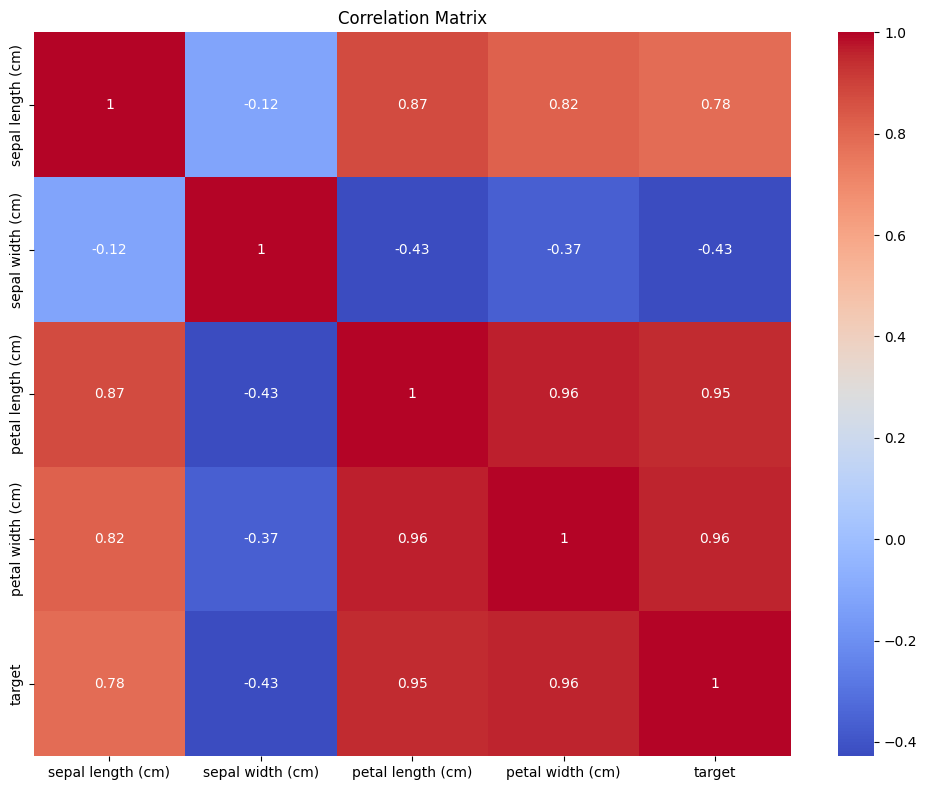

In [121]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

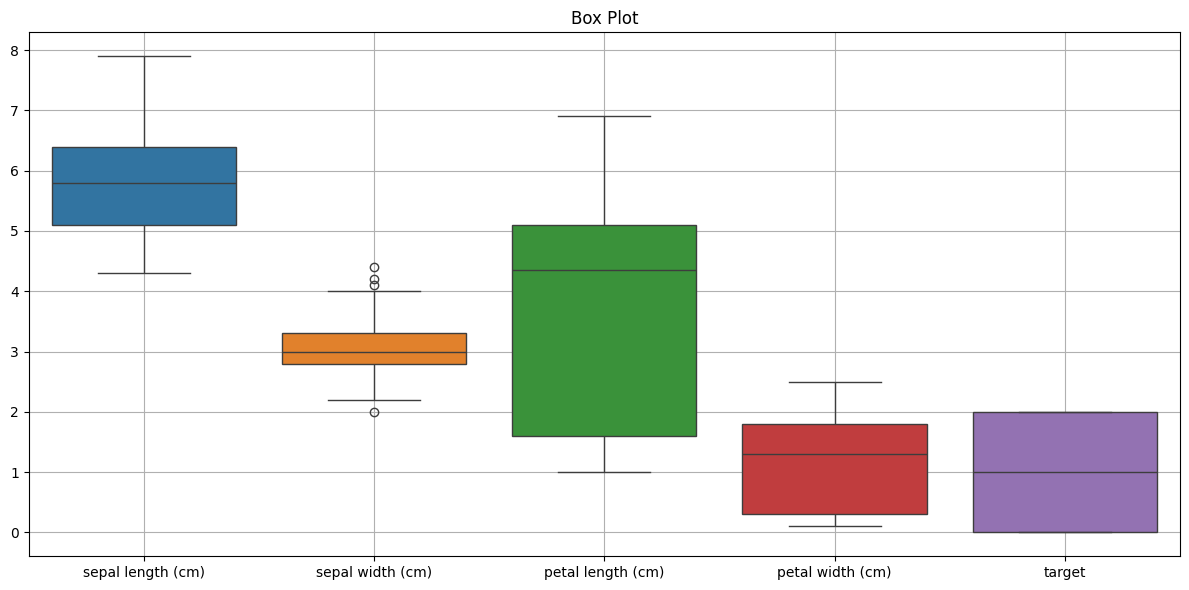

In [122]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.grid()
plt.title('Box Plot')
plt.tight_layout()
plt.show()

In [123]:
target_names = ['setosa', 'versicolor', 'virginica']

# Define The Area from The width and Length
df['sepal area (cm2)'] = df.apply(lambda x : x['sepal length (cm)'] * x['sepal width (cm)'],axis=1)
df['petal area (cm2)'] = df.apply(lambda x : x['petal length (cm)'] * x['petal width (cm)'],axis=1)
# Define Ratio
df['sepal ratio'] = df.apply(lambda x : x['sepal length (cm)'] / x['sepal width (cm)'],axis=1)
df['petal ratio'] = df.apply(lambda x : x['petal length (cm)'] / x['petal width (cm)'],axis=1)
# Define Diagonal
df['sepal Diagonal (cm)'] = df.apply(lambda x : np.sqrt(x['sepal length (cm)']**2 + x['sepal width (cm)']**2),axis=1)
df['petal Diagonal (cm)'] = df.apply(lambda x : np.sqrt(x['petal length (cm)']**2 + x['petal width (cm)']**2),axis=1)
# Define Mean
df['sepal mean'] = df.apply(lambda x : (x['sepal length (cm)'] + x['sepal width (cm)']) / 2,axis=1)
df['petal mean'] = df.apply(lambda x : (x['petal length (cm)'] + x['petal width (cm)']) / 2,axis=1)
# Define The Difference
df['sepal difference'] = df.apply(lambda x : x['sepal length (cm)'] - x['sepal width (cm)'],axis=1)
df['petal difference'] = df.apply(lambda x : x['petal length (cm)'] - x['petal width (cm)'],axis=1)

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,sepal area (cm2),petal area (cm2),sepal ratio,petal ratio,sepal Diagonal (cm),petal Diagonal (cm),sepal mean,petal mean,sepal difference,petal difference
0,5.1,3.5,1.4,0.2,0,17.85,0.28,1.457143,7.000000,6.185467,1.414214,4.30,0.80,1.6,1.2
1,4.9,3.0,1.4,0.2,0,14.70,0.28,1.633333,7.000000,5.745433,1.414214,3.95,0.80,1.9,1.2
2,4.7,3.2,1.3,0.2,0,15.04,0.26,1.468750,6.500000,5.685948,1.315295,3.95,0.75,1.5,1.1
3,4.6,3.1,1.5,0.2,0,14.26,0.30,1.483871,7.500000,5.547071,1.513275,3.85,0.85,1.5,1.3
4,5.0,3.6,1.4,0.2,0,18.00,0.28,1.388889,7.000000,6.161169,1.414214,4.30,0.80,1.4,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,20.10,11.96,2.233333,2.260870,7.340981,5.685948,4.85,3.75,3.7,2.9
146,6.3,2.5,5.0,1.9,2,15.75,9.50,2.520000,2.631579,6.777905,5.348832,4.40,3.45,3.8,3.1
147,6.5,3.0,5.2,2.0,2,19.50,10.40,2.166667,2.600000,7.158911,5.571355,4.75,3.60,3.5,3.2
148,6.2,3.4,5.4,2.3,2,21.08,12.42,1.823529,2.347826,7.071068,5.869412,4.80,3.85,2.8,3.1


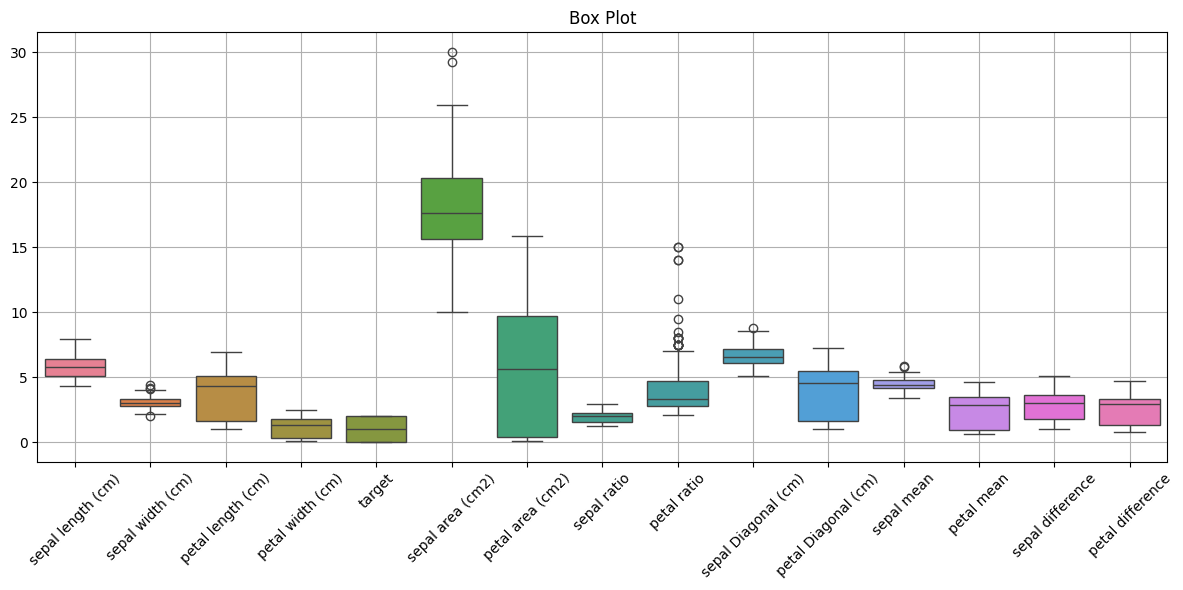

In [137]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.grid()
plt.title('Box Plot')
plt.tight_layout()
plt.show()

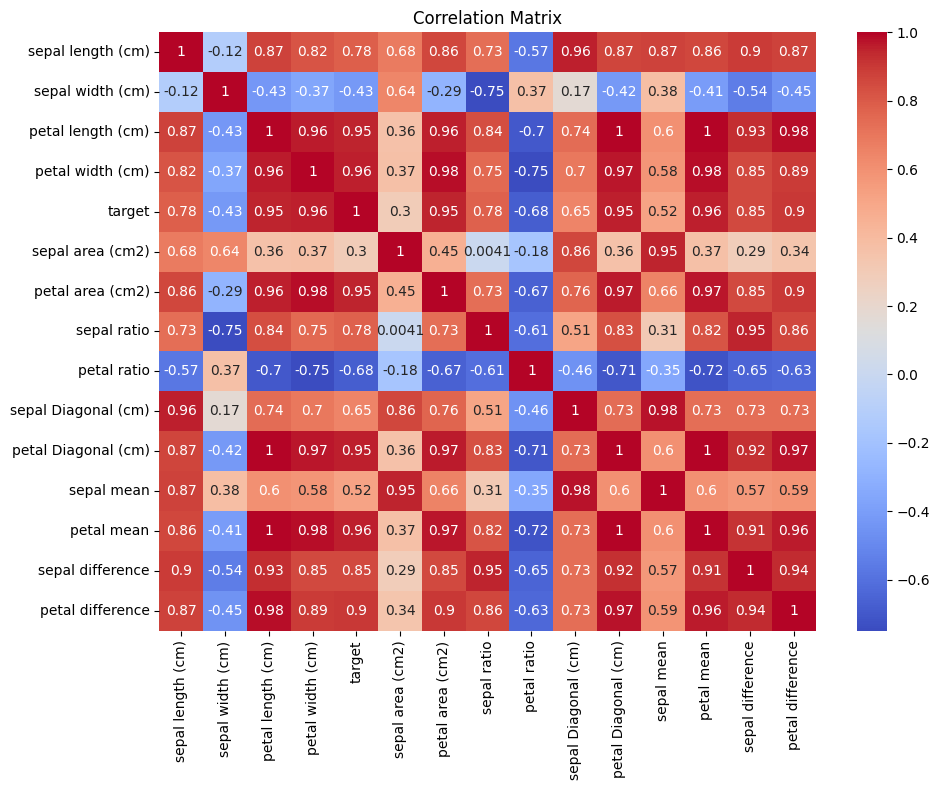

In [124]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [141]:
X = df.drop('target',axis=1)
y = df['target']
FeatureSelection = SelectKBest(chi2,k=10)
X_Selected = FeatureSelection.fit_transform(X,y)

X_Selected_df = pd.DataFrame(X_Selected,columns=[i for i,j in zip(X.columns , FeatureSelection.get_support()) if j])
X_Selected_df

,sepal length (cm),petal length (cm),petal width (cm),sepal area (cm2),petal area (cm2),petal ratio,petal Diagonal (cm),petal mean,sepal difference,petal difference
0,5.1,1.4,0.2,17.85,0.28,7.000000,1.414214,0.80,1.6,1.2
1,4.9,1.4,0.2,14.70,0.28,7.000000,1.414214,0.80,1.9,1.2
2,4.7,1.3,0.2,15.04,0.26,6.500000,1.315295,0.75,1.5,1.1
3,4.6,1.5,0.2,14.26,0.30,7.500000,1.513275,0.85,1.5,1.3
4,5.0,1.4,0.2,18.00,0.28,7.000000,1.414214,0.80,1.4,1.2
...,...,...,...,...,...,...,...,...,...,...
145,6.7,5.2,2.3,20.10,11.96,2.260870,5.685948,3.75,3.7,2.9
146,6.3,5.0,1.9,15.75,9.50,2.631579,5.348832,3.45,3.8,3.1
147,6.5,5.2,2.0,19.50,10.40,2.600000,5.571355,3.60,3.5,3.2
148,6.2,5.4,2.3,21.08,12.42,2.347826,5.869412,3.85,2.8,3.1


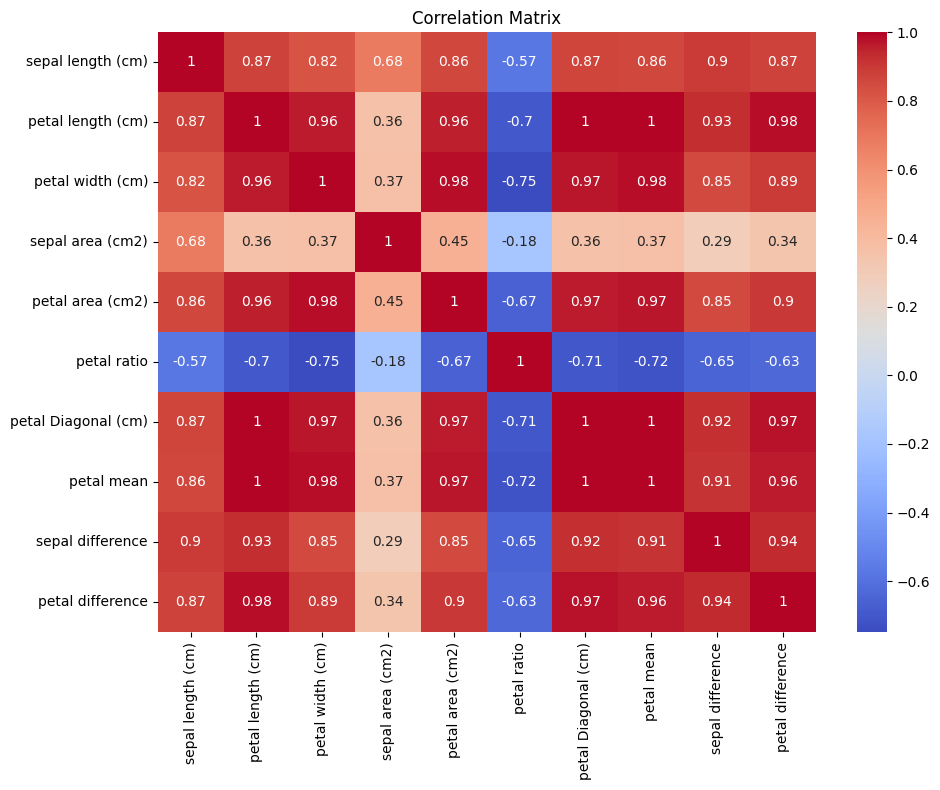

In [142]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_Selected_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [170]:
LogisticReg = LogisticRegression()
RidgeClass = RidgeClassifier()
RandomForest = RandomForestClassifier(n_estimators=100 , criterion='gini',max_depth=2)
GradientBoostClass = GradientBoostingClassifier(n_estimators=100,max_depth=2)

In [175]:
for model in [LogisticReg,RidgeClass,RandomForest,GradientBoostClass]:
    print(f"Model Name: {model.__class__.__name__}")
    CV_Score = cross_val_score(model,X,y,cv=5)
    print(np.round(CV_Score.mean(),3))

Model Name: LogisticRegression
0.98
Model Name: RidgeClassifier
0.953
Model Name: RandomForestClassifier
0.967
Model Name: GradientBoostingClassifier
0.973
